## Import libraries

In [228]:
import os, json, hashlib, glob
from dataclasses import dataclass, asdict

import numpy as np
import matplotlib.pyplot as plt
from tqdm.auto import tqdm

# --- optional MP4 writer (imageio preferred) ---
try:
    import imageio.v2 as imageio
    _HAS_IMAGEIO = True
except Exception:
    _HAS_IMAGEIO = False

## Defining Setting

In [229]:
@dataclass
class Config:
    # Lattice
    L: int = 200
    neighborhood: str = "4"       # "4" or "8"
    include_self: bool = False

    # Dynamics
    omega: float = 0.2        # intensity of selection (Fermi)
    record_every: int = 1        # record rho every N sweeps
    seed: int = 0

    # Scans
    rho0_values: tuple = (0.1,0.5, 0.9)
    
    game_pairs: tuple = ( (0.5,-0.8), (-0.2,0.2)
                           )  # (D_g, D_r)

    runs_per_setting: int = 1

    # Output
    out_dir: str = "results_fixed_game_scan"
    fig_dir: str = "fixed_game_scan_images"
    snap_root: str = "snapshots"
    chk_root: str = "checkpoints"
    video_dir: str = "fixed_game_scan_videos"

cfg = Config()

## Game played representation in Dilemma Space

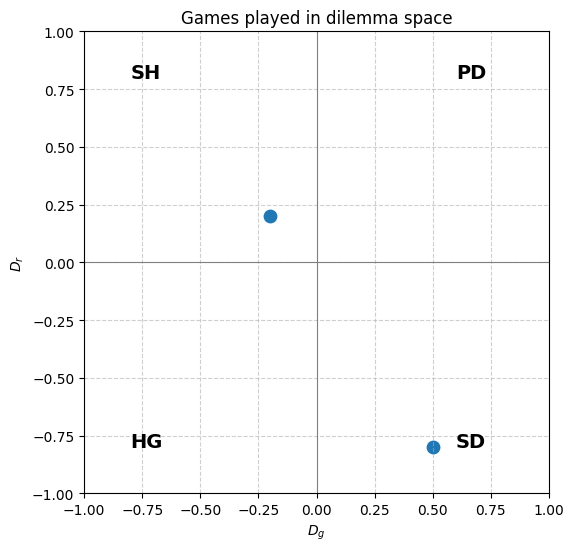

In [230]:
import os
import matplotlib.pyplot as plt

os.makedirs("fixed_game_scan_images", exist_ok=True)

Dg = [g for g, r in cfg.game_pairs]
Dr = [r for g, r in cfg.game_pairs]

plt.figure(figsize=(6, 6))
plt.scatter(Dg, Dr, s=80)

plt.axhline(0, color="gray", lw=0.8)
plt.axvline(0, color="gray", lw=0.8)

plt.xlim(-1, 1)
plt.ylim(-1, 1)

plt.text(-0.8,  0.8, "SH", fontsize=14, weight="bold")
plt.text( 0.6,  0.8, "PD", fontsize=14, weight="bold")
plt.text(-0.8, -0.8, "HG", fontsize=14, weight="bold")
plt.text( 0.6, -0.8, "SD", fontsize=14, weight="bold")

plt.xlabel(r"$D_g$")
plt.ylabel(r"$D_r$")
plt.title("Games played in dilemma space")
plt.grid(True, linestyle="--", alpha=0.6)

save_path = "fixed_game_scan_images/dilemma_space_plot.png"
#plt.savefig(save_path, dpi=300)
plt.show()

#print("Saved to:", os.path.abspath(save_path))




## Neighbourhood and Game Definition

In [231]:
# =========================
def safe_tag(x) -> str:
    s = f"{float(x):.6g}"
    return s.replace("-", "m").replace(".", "p")

def omega_tag() -> str:
    return f"omega_{safe_tag(cfg.omega)}"

def self_tag() -> str:
    return "self_on" if cfg.include_self else "self_off"

def get_offsets(kind: str):
    if kind == "4":
        return [(-1,0),(1,0),(0,-1),(0,1)]
    if kind == "8":
        return [(-1,0),(1,0),(0,-1),(0,1),
                (-1,-1),(-1,1),(1,-1),(1,1)]
    raise ValueError("neighborhood must be '4' or '8'")

OFFSETS = get_offsets(cfg.neighborhood)

# Strategies
C, D = 0, 1

def G_from_D(D_g: float, D_r: float) -> np.ndarray:
    # Payoff matrix:
    # rows = focal (C=0, D=1)
    # cols = opponent (C=0, D=1)
    # [[R, S], [T, P]] with R=1, P=0, S=-Dr, T=1+Dg
    return np.array([[1.0, -float(D_r)],
                     [1.0 + float(D_g), 0.0]], dtype=np.float64)

def fermi_prob(payoff_model: float, payoff_focal: float) -> float:
    # P(focal imitates model) = 1 / (1 + exp(-omega*(model - focal)))
    return 1.0 / (1.0 + np.exp(-cfg.omega * (payoff_model - payoff_focal)))

def init_lattice(rng: np.random.Generator, rho0: float) -> np.ndarray:
    return rng.choice([C, D], size=(cfg.L, cfg.L), p=[rho0, 1.0 - rho0]).astype(np.int8)


## Functions for the dynamics of the system

In [232]:
def site_payoff(latt: np.ndarray, i: int, j: int, G: np.ndarray) -> float:
    s = int(latt[i, j])
    p = 0.0
    if cfg.include_self:
        p += G[s, s]
    for di, dj in OFFSETS:
        ni, nj = (i + di) % cfg.L, (j + dj) % cfg.L
        p += G[s, int(latt[ni, nj])]
    return p

def recompute_all_payoffs(latt: np.ndarray, G: np.ndarray) -> np.ndarray:
    pf = np.zeros((cfg.L, cfg.L), dtype=np.float64)
    for i in range(cfg.L):
        for j in range(cfg.L):
            pf[i, j] = site_payoff(latt, i, j, G)
    return pf

def affected_sites(i: int, j: int):
    sites = {(i, j)}
    for di, dj in OFFSETS:
        sites.add(((i + di) % cfg.L, (j + dj) % cfg.L))
    return list(sites)

def elementary_update(latt: np.ndarray, pf: np.ndarray, G: np.ndarray,
                      rng: np.random.Generator, nC: int) -> int:
    i = int(rng.integers(0, cfg.L))
    j = int(rng.integers(0, cfg.L))

    di, dj = OFFSETS[int(rng.integers(0, len(OFFSETS)))]
    ni, nj = (i + di) % cfg.L, (j + dj) % cfg.L

    pi_X = pf[i, j]
    pi_Y = pf[ni, nj]

    # X imitates Y with Fermi probability
    if rng.random() < fermi_prob(pi_Y, pi_X):
        old_s = int(latt[i, j])
        new_s = int(latt[ni, nj])
        if new_s != old_s:
            latt[i, j] = new_s

            if old_s == C and new_s == D:
                nC -= 1
            elif old_s == D and new_s == C:
                nC += 1

            for ai, aj in affected_sites(i, j):
                pf[ai, aj] = site_payoff(latt, ai, aj, G)

    return nC

def mcs(latt: np.ndarray, pf: np.ndarray, G: np.ndarray,
        rng: np.random.Generator, nC: int) -> int:
    for _ in range(cfg.L * cfg.L):
        nC = elementary_update(latt, pf, G, rng, nC)
    return nC

## Storing Results

In [233]:
def results_paths(D_g, D_r, rho0, r):
    base = (
        f"{omega_tag()}__{self_tag()}__"
        f"Dg_{safe_tag(D_g)}_Dr_{safe_tag(D_r)}_"
        f"rho0_{safe_tag(rho0)}_run_{r}"
    )
    folder = os.path.join(cfg.out_dir, omega_tag(), self_tag(), base)
    os.makedirs(folder, exist_ok=True)
    return folder, os.path.join(folder, "results.npz"), os.path.join(folder, "metadata.json")

def snapshots_folder(D_g, D_r, rho0, r):
    base = (
        f"snaps__{omega_tag()}__{self_tag()}__"
        f"Dg_{safe_tag(D_g)}_Dr_{safe_tag(D_r)}_"
        f"rho0_{safe_tag(rho0)}_run_{r}"
    )
    folder = os.path.join(cfg.snap_root, omega_tag(), self_tag(), base)
    os.makedirs(folder, exist_ok=True)
    return folder

def checkpoint_path(D_g, D_r, rho0, r):
    name = (
        f"chk__{omega_tag()}__{self_tag()}__"
        f"Dg_{safe_tag(D_g)}_Dr_{safe_tag(D_r)}_"
        f"rho0_{safe_tag(rho0)}_run_{r}.npz"
    )
    folder = os.path.join(cfg.chk_root, omega_tag(), self_tag())
    os.makedirs(folder, exist_ok=True)
    return os.path.join(folder, name)

def append_rho_series(save_npz, save_meta, rho_new, meta_update: dict):
    # append rho_series
    if os.path.exists(save_npz):
        old = np.load(save_npz, allow_pickle=True)
        rho_old = old["rho_series"]
        rho_all = np.concatenate([rho_old, rho_new])
    else:
        rho_all = rho_new

    np.savez_compressed(save_npz, rho_series=rho_all)

    meta = dict(meta_update)
    meta["recorded_points_total"] = int(len(rho_all))
    with open(save_meta, "w", encoding="utf-8") as f:
        json.dump(meta, f, indent=2, sort_keys=True)


## Checkpoint Loading and Saving 

In [234]:
def save_checkpoint(path, latt, pf, nC, sweep, rng):
    np.savez(
        path,
        latt=latt,
        pf=pf,
        nC=int(nC),
        sweep=int(sweep),
        rng_state=rng.bit_generator.state
    )

def load_checkpoint(path, rng):
    chk = np.load(path, allow_pickle=True)
    rng.bit_generator.state = chk["rng_state"].item()
    return chk["latt"], chk["pf"], int(chk["nC"]), int(chk["sweep"])




## Utilities to visualise the data

In [235]:
def plot_rho(D_g, D_r, rho0, r):
    os.makedirs(os.path.join(cfg.fig_dir, omega_tag(), self_tag()), exist_ok=True)
    folder, save_npz, _ = results_paths(D_g, D_r, rho0, r)
    data = np.load(save_npz, allow_pickle=True)
    rho = data["rho_series"]
    sweeps = np.arange(len(rho)) * cfg.record_every

    plt.figure(figsize=(10,6))
    plt.plot(sweeps, rho, lw=2)
    plt.xlabel("Monte Carlo sweeps")
    plt.ylabel(r"$\rho$")
    plt.ylim(0,1)
    plt.grid(True)
    plt.title(f"Fixed game: (Dg,Dr)=({D_g},{D_r}), rho0={rho0}, run={r}")
    plt.tight_layout()

    out = os.path.join(cfg.fig_dir, omega_tag(), self_tag(),
                       f"rho__Dg_{safe_tag(D_g)}_Dr_{safe_tag(D_r)}_rho0_{safe_tag(rho0)}_run_{r}.png")
    plt.savefig(out, dpi=250)
    plt.close()
    return out

def snaps_to_mp4(D_g, D_r, rho0, r, fps=10):
    os.makedirs(cfg.video_dir, exist_ok=True)
    sdir = snapshots_folder(D_g, D_r, rho0, r)
    files = sorted(glob.glob(os.path.join(sdir, "snap_*.png")))
    if not files:
        raise FileNotFoundError(f"No snapshots found in: {sdir}")

    out = os.path.join(
        cfg.video_dir,
        f"lattice__{omega_tag()}__{self_tag()}__"
        f"Dg_{safe_tag(D_g)}_Dr_{safe_tag(D_r)}_"
        f"rho0_{safe_tag(rho0)}_run_{r}.mp4"
    )

    if _HAS_IMAGEIO:
        with imageio.get_writer(out, fps=fps, codec="libx264") as w:
            for f in files:
                w.append_data(imageio.imread(f))
    else:
        # fallback: try matplotlib ffmpeg writer
        import matplotlib.pyplot as plt
        from matplotlib.animation import FuncAnimation, FFMpegWriter

        fig, ax = plt.subplots()
        im = ax.imshow(plt.imread(files[0]), cmap="gray")
        ax.axis("off")

        def update(k):
            im.set_data(plt.imread(files[k]))
            return (im,)

        ani = FuncAnimation(fig, update, frames=len(files), interval=1000/fps, blit=True)
        ani.save(out, writer=FFMpegWriter(fps=fps))
        plt.close(fig)

    return out

## One run function

In [236]:
# =========================
# 7) RUN ONCE (RESUMABLE, SAFE APPEND)
# =========================
def run_once_lattice_fixed_game(
    rho0, D_g, D_r,
    seed_offset=0,
    checkpoint_every=100,
    snap_every=20,
    extra_sweeps=200
):
    # --- SAFETY: alignment conditions for clean resume+append ---
    assert checkpoint_every % cfg.record_every == 0, "checkpoint_every must be multiple of record_every"
    assert extra_sweeps % cfg.record_every == 0, "extra_sweeps must be multiple of record_every"

    rng = np.random.default_rng(cfg.seed + seed_offset)

    chk = checkpoint_path(D_g, D_r, rho0, seed_offset // 10000 if seed_offset else 0)  # not used directly
    # (we'll pass explicit chk path from main; kept here only to show logic)

    G = G_from_D(D_g, D_r)
    L2 = cfg.L * cfg.L

    return rng, G, L2

def run_chunk_with_io(
    rho0, D_g, D_r, r,
    seed_offset,
    chk_path,
    snap_dir,
    checkpoint_every,
    snap_every,
    extra_sweeps
):
    # SAFETY
    assert checkpoint_every % cfg.record_every == 0
    assert extra_sweeps % cfg.record_every == 0

    rng = np.random.default_rng(cfg.seed + seed_offset)
    G = G_from_D(D_g, D_r)
    L2 = cfg.L * cfg.L

    resumed = False

    # load or init
    if os.path.exists(chk_path):
        latt, pf, nC, start_sweep = load_checkpoint(chk_path, rng)
        resumed = True
    else:
        latt = init_lattice(rng, rho0)
        pf = recompute_all_payoffs(latt, G)
        nC = int(np.sum(latt == C))
        start_sweep = 0
        save_checkpoint(chk_path, latt, pf, nC, start_sweep, rng)

    # initial snapshot at start_sweep if missing
    init_snap = os.path.join(snap_dir, f"snap_{start_sweep:07d}.png")
    if not os.path.exists(init_snap):
        plt.imsave(init_snap, latt, vmin=0, vmax=1, cmap="gray")

    rho_series = []
    
    if start_sweep == 0:
        rho_series.append(nC / L2)

    end_sweep = start_sweep + int(extra_sweeps)

    # IMPORTANT: resume from next sweep, but record/checkpoint rules aligned => no duplicates
    for sweep_idx in range(start_sweep + 1, end_sweep + 1):
        nC = mcs(latt, pf, G, rng, nC)

        if (sweep_idx % snap_every == 0):
            plt.imsave(os.path.join(snap_dir, f"snap_{sweep_idx:07d}.png"),
                       latt, vmin=0, vmax=1, cmap="gray")

        if (sweep_idx % checkpoint_every == 0):
            save_checkpoint(chk_path, latt, pf, nC, sweep_idx, rng)

        if (sweep_idx % cfg.record_every == 0):
            rho_series.append(nC / L2)

    # final checkpoint
    save_checkpoint(chk_path, latt, pf, nC, end_sweep, rng)

    return np.array(rho_series, dtype=np.float64), resumed, start_sweep



# Run Experiment

In [237]:
def main():
    # Make dirs
    os.makedirs(cfg.out_dir, exist_ok=True)
    os.makedirs(cfg.fig_dir, exist_ok=True)
    os.makedirs(cfg.snap_root, exist_ok=True)
    os.makedirs(cfg.chk_root, exist_ok=True)
    os.makedirs(cfg.video_dir, exist_ok=True)

    # Choose these carefully (must satisfy alignment constraints)
    checkpoint_every = 100   # multiple of record_every
    extra_sweeps = 0  # multiple of record_every
    snap_every = 50        # independent from record/checkpoint ok

    assert checkpoint_every % cfg.record_every == 0
    assert extra_sweeps % cfg.record_every == 0

    for (D_g, D_r) in cfg.game_pairs:
        for rho0 in cfg.rho0_values:
            for r in tqdm(range(cfg.runs_per_setting),
                          desc=f"Game=({D_g},{D_r}) rho0={rho0}",
                          dynamic_ncols=True):

                chk = checkpoint_path(D_g, D_r, rho0, r)
                snap_dir = snapshots_folder(D_g, D_r, rho0, r)

                rho_chunk, resumed, start_sweep = run_chunk_with_io(
                    rho0, D_g, D_r, r,
                    seed_offset=10000 * r,
                    chk_path=chk,
                    snap_dir=snap_dir,
                    checkpoint_every=checkpoint_every,
                    snap_every=snap_every,
                    extra_sweeps=extra_sweeps
                )

                folder, save_npz, save_meta = results_paths(D_g, D_r, rho0, r)

                # overwrite results only if NOT resumed but file exists (true fresh restart)
                if (not resumed) and os.path.exists(save_npz):
                    os.remove(save_npz)

                meta_update = {
                    "model": "Fixed-game lattice (safe resume+append)",
                    "config": asdict(cfg),
                    "G_fixed": {"D_g": float(D_g), "D_r": float(D_r)},
                    "rho0": float(rho0),
                    "run": int(r),
                    "checkpoint_path": chk,
                    "snap_dir": snap_dir,
                    "resumed_from_checkpoint": bool(resumed),
                    "start_sweep_loaded": int(start_sweep),
                    "omega": float(cfg.omega),
                    "include_self": bool(cfg.include_self),
                    "notes": "checkpoint_every and extra_sweeps aligned to record_every to avoid duplicates/gaps."
                }

                append_rho_series(save_npz, save_meta, rho_chunk, meta_update)

                #fig_path = plot_rho(D_g, D_r, rho0, r)
                #mp4_path = snaps_to_mp4(D_g, D_r, rho0, r, fps=8)

                #print("Saved:", save_npz)
                #print("Plot:", os.path.abspath(fig_path))
                #print("MP4 :", os.path.abspath(mp4_path))
                print("Resumed?", resumed, "start_sweep:", start_sweep)

if __name__ == "__main__":
    main()



Game=(0.5,-0.8) rho0=0.1: 100%|██████████| 1/1 [00:00<00:00,  6.17it/s]


Resumed? True start_sweep: 2400


Game=(0.5,-0.8) rho0=0.5: 100%|██████████| 1/1 [00:00<00:00, 14.95it/s]


Resumed? True start_sweep: 3700


Game=(0.5,-0.8) rho0=0.9: 100%|██████████| 1/1 [00:00<00:00, 14.79it/s]


...

Resumed?

Game=(-0.2,0.2) rho0=0.5: 100%|██████████| 1/1 [00:00<00:00, 20.65it/s]


 True start_sweep: 6000


Game=(-0.2,0.2) rho0=0.9: 100%|██████████| 1/1 [00:00<00:00, 20.47it/s]

Resumed? True start_sweep: 6000


## Plot cooperation over time for a fixed game for different initial cooperation values

In [238]:
import os
import numpy as np
import matplotlib.pyplot as plt

# Assumes these already exist from your simulation code:
# - cfg (needs cfg.out_dir and cfg.record_every)
# - safe_tag(x)  -> e.g. 0.2 -> "0p2", -0.1 -> "m0p1"
# - self_tag()   -> "self_on" or "self_off"

def omega_tag_from_value(omega: float) -> str:
    """Match your tagging convention used in folder names."""
    s = f"{float(omega):.6g}"
    s = s.replace("-", "m").replace(".", "p")
    return f"omega_{s}"

def results_path_for(D_g, D_r, rho0, omega, run=0) -> str:
    """Build the exact path to results.npz without using cfg.omega."""
    omtag = omega_tag_from_value(omega)

    folder = (
        f"{omtag}__{self_tag()}__"
        f"Dg_{safe_tag(D_g)}_Dr_{safe_tag(D_r)}_"
        f"rho0_{safe_tag(rho0)}_run_{run}"
    )

    return os.path.join(
        cfg.out_dir,   # e.g. "results_fixed_game_scan"
        omtag,         # e.g. "omega_10"
        self_tag(),    # e.g. "self_on"
        folder,
        "results.npz"
    )

def plot_rho_for_games(
    game_pairs,
    rho0_list,
    omega,
    run=0,
    out_dir="fixed_game_scan_images",
    save=True,
    show_missing=True
):
    """
    For each (Dg,Dr) in game_pairs, plot rho(t) curves for all rho0 in rho0_list.
    Saves each figure into:
        out_dir/<omega_tag>[/<self_tag>]/...
    """
    omtag = omega_tag_from_value(omega)

    # Save inside fixed_game_scan_images/omega_X/self_on (cleaner)
    save_dir = os.path.join(out_dir, omtag, self_tag())
    os.makedirs(save_dir, exist_ok=True)

    for (D_g, D_r) in game_pairs:
        plt.figure(figsize=(10, 6))
        found_any = False

        for rho0 in rho0_list:
            path = results_path_for(D_g, D_r, rho0, omega, run=run)

            if not os.path.exists(path):
                if show_missing:
                    print("Missing:", path)
                continue

            rho = np.load(path, allow_pickle=True)["rho_series"]
            sweeps = np.arange(len(rho)) * cfg.record_every
            plt.plot(sweeps, rho, lw=2, label=f"rho0={rho0}")
            found_any = True

        if not found_any:
            plt.close()
            continue

        plt.xlabel("Monte Carlo sweeps")
        plt.ylabel(r"$\rho$")
        plt.ylim(0, 1)
        plt.grid(True)
        plt.legend()
        plt.tight_layout()

        filename = os.path.join(
            save_dir,
            f"rho_vs_sweeps__Dg_{safe_tag(D_g)}__Dr_{safe_tag(D_r)}__"
            f"{omtag}__{self_tag()}__run_{run}.png"
        )

        if save:
            plt.savefig(filename, dpi=300)
            print("Saved:", os.path.abspath(filename))

        plt.close()

# -------------------------
# EXAMPLE USAGE
# -------------------------


In [ ]:
my_games = [
    (0.2,0.2), (0.2,0.5), (0.2,0.8),
    (0.5,0.2), (0.5,0.5), (0.5,0.8),
    (0.8,0.2), (0.8,0.5), (0.8,0.8),
    (-0.2,0.2), (-0.2,0.5), (-0.2,0.8),
    (-0.5,0.2), (-0.5,0.5), (-0.5,0.8),
    (-0.8,0.2), (-0.8,0.5), (-0.8,0.8),
    (0.2,-0.2), (0.2,-0.5), (0.2,-0.8),
    (0.5,-0.2), (0.5,-0.5), (0.5,-0.8),
    (0.8,-0.2), (0.8,-0.5), (0.8,-0.8),
    (-0.8,-0.2), (-0.8,-0.5), (-0.8,-0.8),
    (-0.5,-0.2), (-0.5,-0.5), (-0.5,-0.8),
    (-0.2,-0.2), (-0.2,-0.5), (-0.2,-0.8),
]

plot_rho_for_games(
    game_pairs=my_games,
    rho0_list=[0.1, 0.5, 0.9],
    omega=0.2,      # choose omega here
    run=0,
    out_dir="fixed_game_scan_images"
)

Missing: results_fixed_game_scan\omega_10\self_on\omega_10__self_on__Dg_0p025_Dr_0_rho0_0p3_run_0\results.npz
Missing: results_fixed_game_scan\omega_10\self_on\omega_10__self_on__Dg_0p025_Dr_0_rho0_0p7_run_0\results.npz
Saved: c:\Users\HP\OneDrive\Python\master_thesis\evolutionary_PD_on_a_square_lattice\fixed_game_scan_images\omega_10\self_on\rho_vs_sweeps__Dg_0p025__Dr_0__omega_10__self_on__run_0.png
Missing: results_fixed_game_scan\omega_10\self_on\omega_10__self_on__Dg_0p075_Dr_0_rho0_0p3_run_0\results.npz
Missing: results_fixed_game_scan\omega_10\self_on\omega_10__self_on__Dg_0p075_Dr_0_rho0_0p7_run_0\results.npz
Saved: c:\Users\HP\OneDrive\Python\master_thesis\evolutionary_PD_on_a_square_lattice\fixed_game_scan_images\omega_10\self_on\rho_vs_sweeps__Dg_0p075__Dr_0__omega_10__self_on__run_0.png
Missing: results_fixed_game_scan\omega_10\self_on\omega_10__self_on__Dg_0p125_Dr_0_rho0_0p3_run_0\results.npz
Missing: results_fixed_game_scan\omega_10\self_on\omega_10__self_on__Dg_0p125_Dr

## Producing a 3x3 image

In [239]:
import os
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.ticker import MaxNLocator

# Assumes you already have these from your codebase:
# - cfg (with cfg.out_dir and cfg.record_every)
# - safe_tag(x)
# - self_tag()
# - omega_tag_from_value(omega)
# - results_path_for(D_g, D_r, rho0, omega, run=0)

def game_class(D_g, D_r):
    if D_g > 0 and D_r > 0:
        return "PD"
    if D_g > 0 and D_r < 0:
        return "SD"
    if D_g < 0 and D_r > 0:
        return "SH"
    if D_g < 0 and D_r < 0:
        return "HG"
    return "axis"  # on axes (Dg==0 or Dr==0)

def plot_9_games_per_class_thesis(
    game_pairs,
    rho0_list,
    omega,
    run=0,
    out_dir="thesis_figures",
    fmt=("pdf", "png"),
    show_missing=False,
    annotate_mcs_max=True,
):
    """
    Creates 4 thesis-ready figures (PD, SD, SH, HG).
    Each figure: 3x3 grid of subplots (your 9 (Dg,Dr) points for that class).
    Each subplot overlays rho(t) for rho0_list.

    IMPORTANT: each subplot is forced to use its OWN MCS extent (xlim set per panel),
    and we keep ticks everywhere to make the different extents visible.
    """

    omtag = omega_tag_from_value(omega)
    save_dir = os.path.join(out_dir, omtag, self_tag())
    os.makedirs(save_dir, exist_ok=True)

    # Split pairs into classes
    by_class = {"PD": [], "SD": [], "SH": [], "HG": [], "axis": []}
    for (D_g, D_r) in game_pairs:
        by_class[game_class(D_g, D_r)].append((D_g, D_r))

    # Plot each class
    for cls in ["PD", "SD", "SH", "HG"]:
        pairs = by_class[cls]
        if len(pairs) == 0:
            continue

        # Sort so grid is nicely ordered: rows by Dr, cols by Dg
        pairs = sorted(pairs, key=lambda x: (x[1], x[0]))

        nrows, ncols = 3, 3
        fig = plt.figure(figsize=(12.0, 9.6), constrained_layout=True)
        gs = fig.add_gridspec(nrows, ncols)

        fig.suptitle(
            fr"{cls} region ($\omega={omega}$, {self_tag().replace('_',' ')})",
            fontsize=16
        )

        axes = [fig.add_subplot(gs[r, c]) for r in range(nrows) for c in range(ncols)]

        legend_handles = None
        legend_labels = None

        for ax, (D_g, D_r) in zip(axes, pairs):
            found_any = False
            last_mcs_max = None

            for rho0 in rho0_list:
                path = results_path_for(D_g, D_r, rho0, omega, run=run)

                if not os.path.exists(path):
                    continue

                z = np.load(path, allow_pickle=True)
                if "rho_series" in z.files:
                    rho = z["rho_series"].astype(float)
                elif "rho" in z.files:
                    rho = z["rho"].astype(float)
                else:
                    continue

                mcs = np.arange(len(rho)) * cfg.record_every
                if len(mcs) == 0:
                    continue

                ax.plot(mcs, rho, lw=1.7, label=fr"$\rho_0={rho0}$")
                found_any = True
                last_mcs_max = float(mcs[-1])

            if not found_any:
                if show_missing:
                    ax.text(0.5, 0.5, "Missing", ha="center", va="center", fontsize=11)
                ax.set_axis_off()
                continue

            # Titles and styling
            ax.set_title(fr"$D_g={D_g}$, $D_r={D_r}$", fontsize=11)
            ax.set_ylim(0, 1)
            ax.grid(True, linestyle="--", alpha=0.35)

            # FORCE each subplot to use its own MCS extent
            ax.set_xlim(0, last_mcs_max if last_mcs_max is not None else 1.0)

            # Make different extents visible: few ticks, small font
            ax.xaxis.set_major_locator(MaxNLocator(4))
            ax.yaxis.set_major_locator(MaxNLocator(4))
            ax.tick_params(axis="x", labelsize=9)
            ax.tick_params(axis="y", labelsize=9)

            # Optional: annotate max MCS for clarity
            '''if annotate_mcs_max and last_mcs_max is not None:
                ax.text(
                    0.02, 0.04, f"MCS max: {int(last_mcs_max)}",
                    transform=ax.transAxes, fontsize=9, alpha=0.85
                )'''

            # Store legend once
            if legend_handles is None:
                legend_handles, legend_labels = ax.get_legend_handles_labels()

        # Turn off unused axes if fewer than 9
        for ax in axes[len(pairs):]:
            ax.set_axis_off()

        # Axis labels: only bottom row & left column (clean thesis look)
        for r in range(nrows):
            for c in range(ncols):
                ax = axes[r * ncols + c]
                if not ax.has_data():
                    continue

                if r == nrows - 1:
                    ax.set_xlabel("MCS", fontsize=11)
                else:
                    ax.set_xlabel("")  # keep ticks, but no xlabel

                if c == 0:
                    ax.set_ylabel(r"$\rho$", fontsize=11)
                else:
                    ax.set_ylabel("")

        # Single legend for the whole figure
        if legend_handles:
            fig.legend(
                legend_handles, legend_labels,
                loc="lower center", ncol=len(rho0_list),
                fontsize=11, frameon=False
            )

        base = f"{cls}__grid_3x3__{omtag}__{self_tag()}__run_{run}"
        for ext in fmt:
            out_path = os.path.join(save_dir, f"{base}.{ext}")
            if ext.lower() == "png":
                fig.savefig(out_path, dpi=350)
            else:
                fig.savefig(out_path)  # pdf is vector
            print("Saved:", os.path.abspath(out_path))

        plt.close(fig)

    if len(by_class["axis"]) > 0:
        print("Note: points on axes (Dg==0 or Dr==0) were not plotted:", by_class["axis"])

In [227]:
my_games = [
    (0.2,0.2), (0.2,0.5), (0.2,0.8),
    (0.5,0.2), (0.5,0.5), (0.5,0.8),
    (0.8,0.2), (0.8,0.5), (0.8,0.8),
    (-0.2,0.2), (-0.2,0.5), (-0.2,0.8),
    (-0.5,0.2), (-0.5,0.5), (-0.5,0.8),
    (-0.8,0.2), (-0.8,0.5), (-0.8,0.8),
    (0.2,-0.2), (0.2,-0.5), (0.2,-0.8),
    (0.5,-0.2), (0.5,-0.5), (0.5,-0.8),
    (0.8,-0.2), (0.8,-0.5), (0.8,-0.8),
    (-0.8,-0.2), (-0.8,-0.5), (-0.8,-0.8),
    (-0.5,-0.2), (-0.5,-0.5), (-0.5,-0.8),
    (-0.2,-0.2), (-0.2,-0.5), (-0.2,-0.8),
]

plot_9_games_per_class_thesis(
    game_pairs=my_games,
    rho0_list=[0.1, 0.5, 0.9],
    omega=0.2,
    run=0,
    out_dir="thesis_figures",
    fmt=("pdf", "png"),
    show_missing=True,       # set False once you’re sure paths are correct
    annotate_mcs_max=True
)

Saved: c:\Users\HP\OneDrive\Python\master_thesis\evolutionary_PD_on_a_square_lattice\thesis_figures\omega_0p2\self_off\PD__grid_3x3__omega_0p2__self_off__run_0.pdf
Saved: c:\Users\HP\OneDrive\Python\master_thesis\evolutionary_PD_on_a_square_lattice\thesis_figures\omega_0p2\self_off\PD__grid_3x3__omega_0p2__self_off__run_0.png
Saved: c:\Users\HP\OneDrive\Python\master_thesis\evolutionary_PD_on_a_square_lattice\thesis_figures\omega_0p2\self_off\SD__grid_3x3__omega_0p2__self_off__run_0.pdf
Saved: c:\Users\HP\OneDrive\Python\master_thesis\evolutionary_PD_on_a_square_lattice\thesis_figures\omega_0p2\self_off\SD__grid_3x3__omega_0p2__self_off__run_0.png
Saved: c:\Users\HP\OneDrive\Python\master_thesis\evolutionary_PD_on_a_square_lattice\thesis_figures\omega_0p2\self_off\SH__grid_3x3__omega_0p2__self_off__run_0.pdf
Saved: c:\Users\HP\OneDrive\Python\master_thesis\evolutionary_PD_on_a_square_lattice\thesis_figures\omega_0p2\self_off\SH__grid_3x3__omega_0p2__self_off__run_0.png
Saved: c:\Users\

## Verifying the results of Szabo and Toke

In [240]:
import os
import numpy as np
import matplotlib.pyplot as plt

# Assumes these exist in your environment (from your sim script):
# - cfg (with cfg.out_dir and cfg.record_every)
# - safe_tag(x)
# - omega_tag()
# - self_tag()

def results_path_for_fixed_game(D_g, D_r, rho0, run=0):
    """
    Must match your simulation folder structure exactly:
    cfg.out_dir/omega_tag()/self_tag()/(base)/results.npz
    where base includes omega_tag and self_tag too.
    """
    base = (
        f"{omega_tag()}__{self_tag()}__"
        f"Dg_{safe_tag(D_g)}_Dr_{safe_tag(D_r)}_"
        f"rho0_{safe_tag(rho0)}_run_{run}"
    )
    return os.path.join(cfg.out_dir, omega_tag(), self_tag(), base, "results.npz")


def plot_final_coop_vs_Dg_single_run_given_couples(
    couples,
    rho0=0.5,
    run=0,
    window_frac=0.10,
    out_dir="fixed_game_scan_images",
    save_name=None,
    show_missing=True
):
    """
    Plots final cooperation (mean of last `window_frac` of recorded points)
    vs D_g, using ONLY the couples you pass.

    Error bars: standard error of rho within the last-window:
        SE = std(window, ddof=1) / sqrt(k)
    """
    os.makedirs(out_dir, exist_ok=True)

    x_list, y_list, e_list = [], [], []

    for (D_g, D_r) in couples:
        path = results_path_for_fixed_game(D_g, D_r, rho0, run=run)

        if not os.path.exists(path):
            if show_missing:
                print("Missing:", path)
            continue

        rho = np.load(path, allow_pickle=True)["rho_series"]
        n = int(len(rho))
        if n == 0:
            if show_missing:
                print("Empty rho_series:", path)
            continue

        k = max(1, int(np.ceil(window_frac * n)))
        window = rho[-k:]

        mean = float(np.mean(window))
        # with k=1, ddof=1 would be invalid; handle safely
        if k >= 2:
            std = float(np.std(window, ddof=1))
            se = std / np.sqrt(k)
        else:
            se = 0.0

        x_list.append(float(D_g))
        y_list.append(mean)
        e_list.append(se)

    if len(x_list) == 0:
        raise RuntimeError(
            "No data found for the couples you passed (check rho0/run/tags/out_dir/CWD)."
        )

    # sort by Dg
    order = np.argsort(x_list)
    x = np.array(x_list)[order]
    y = np.array(y_list)[order]
    e = np.array(e_list)[order]

    plt.figure(figsize=(8, 6))
    plt.plot(x, y, marker="o", lw=2)
    plt.errorbar(x, y, yerr=e, fmt="none", capsize=3)

    plt.xlabel(r"$D_g$")
    plt.ylabel(r"Final cooperation $\bar{\rho}$ (mean of last 10%)")
    plt.ylim(0, 1)
    plt.grid(True)
    plt.tight_layout()

    if save_name is None:
        save_name = (
            f"final_coop_vs_Dg__rho0_{safe_tag(rho0)}__run_{run}__"
            f"window_{int(window_frac*100)}pct__{omega_tag()}__{self_tag()}.png"
        )

    out_path = os.path.join(out_dir, save_name)
    #plt.savefig(out_path, dpi=300)
    plt.show()

    #print("Saved:", os.path.abspath(out_path))
    return x, y, e


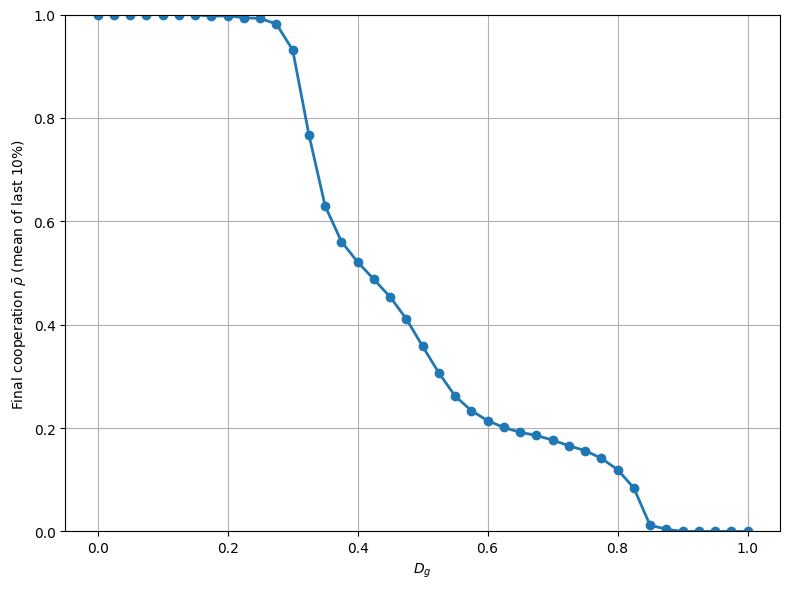

In [146]:
my_couples = [
    (0.0, 0.0), (0.025, 0.0), (0.05, 0.0), (0.075,0), (0.1, 0.0), (0.125, 0.0), (0.15, 0.0), (0.175, 0.0), (0.2, 0.0),
    (0.225, 0.0),  (0.25, 0.0),(0.275, 0.0), (0.3, 0.0), (0.325, 0.0), (0.35, 0.0), (0.375, 0.0), (0.4, 0.0), 
    (0.425, 0.0), (0.45, 0.0), (0.475, 0.0),
    (0.5, 0.0), (0.55, 0.0), (0.6, 0.0), (0.65, 0.0), (0.7, 0.0),
    (0.75, 0.0), (0.8, 0.0), (0.85, 0.0), (0.9, 0.0), (0.95, 0.0),
    (1.0, 0.0), (0.525,0), (0.575,0), (0.625,0), (0.675,0), (0.725,0),
                          (0.775,0), (0.825,0), (0.875,0), (0.925,0), (0.975,0),
]

old_omega = cfg.omega
cfg.omega = 10

x, y, e = plot_final_coop_vs_Dg_single_run_given_couples(
    couples=my_couples,
    rho0=0.5,
    run=0,
    window_frac=0.10
)

cfg.omega = old_omega  # restore

## Comparison with the Results Predicted by the Replicator Equation on Graphs

In [242]:
import os
import glob
import json
import numpy as np

# Optional but recommended
try:
    import pandas as pd
    _HAS_PANDAS = True
except Exception:
    _HAS_PANDAS = False


# =========================================================
# 1) USER SETTINGS (edit these)
# =========================================================

RESULTS_ROOT = "results_fixed_game_scan"   # where your run folders are
OUT_DIR = "comparison_tables"             # output CSVs
WINDOW_FRAC = 0.10                        # last 10% of recorded points

# --- choose the games you want to analyse (D_g, D_r) ---
# Use None to analyse ALL games found.
SELECT_GAMES = [
    (0.2,0.2), (0.2,0.5), (0.2,0.8),
    (0.5,0.2), (0.5,0.5), (0.5,0.8),
    (0.8,0.2), (0.8,0.5), (0.8,0.8),
    (-0.2,0.2), (-0.2,0.5), (-0.2,0.8),
    (-0.5,0.2), (-0.5,0.5), (-0.5,0.8),
    (-0.8,0.2), (-0.8,0.5), (-0.8,0.8),
    (0.2,-0.2), (0.2,-0.5), (0.2,-0.8),
    (0.5,-0.2), (0.5,-0.5), (0.5,-0.8),
    (0.8,-0.2), (0.8,-0.5), (0.8,-0.8),
    (-0.8,-0.2), (-0.8,-0.5), (-0.8,-0.8),
    (-0.5,-0.2), (-0.5,-0.5), (-0.5,-0.8),
    (-0.2,-0.2), (-0.2,-0.5), (-0.2,-0.8),
]
# SELECT_GAMES = None

# Matching tolerance for floats (important!)
GAME_TOL = 1e-9

# --- optional filters (set to None to disable) ---
FILTER_OMEGA = 0.2           # e.g. 0.2, or None
FILTER_INCLUDE_SELF = False  # e.g. False, or None
FILTER_NEIGHBORHOOD = "4"    # "4" or "8", or None
FILTER_RHO0 = 0.5            # e.g. 0.5, or None


# =========================================================
# 2) HELPERS
# =========================================================

def matches_pair(D_g, D_r, wanted_pairs, tol=1e-9) -> bool:
    if wanted_pairs is None:
        return True
    for a, b in wanted_pairs:
        if abs(D_g - a) <= tol and abs(D_r - b) <= tol:
            return True
    return False


def tail_window_stats(rho_series: np.ndarray, frac: float = 0.10):
    """
    Mean/std over the last frac fraction of points.
    Works for variable-length runs.
    """
    n = int(len(rho_series))
    if n == 0:
        return np.nan, np.nan, 0, 0
    w = max(1, int(np.floor(frac * n)))
    tail = rho_series[-w:]
    mean = float(np.mean(tail))
    std = float(np.std(tail, ddof=1)) if w > 1 else 0.0
    return mean, std, int(w), int(n)


def degree_from_neighborhood(neighborhood: str) -> int:
    if str(neighborhood) == "4":
        return 4
    if str(neighborhood) == "8":
        return 8
    raise ValueError(f"Unknown neighborhood: {neighborhood}")


# =========================================================
# 3) REPLICATOR-ON-GRAPHS PREDICTION (BD/PC weak-selection formula)
# =========================================================

def rho_star_graph(D_g: float, D_r: float, k: int):
    denom = (D_r - D_g)
    if abs(denom) < 1e-12:
        return None
    return (D_r + (D_r + D_g) / (k - 2)) / denom


def L_rho(D_g: float, D_r: float, k: int, rho: float) -> float:
    return rho * (D_r - D_g) - D_r - (D_r + D_g) / (k - 2)


def stable_fixed_point_graph(D_g: float, D_r: float, k: int):
    """
    Returns:
      rho_pred (float or nan), pred_type
    """
    rho0_stable = (L_rho(D_g, D_r, k, 0.0) < 0.0)
    rho1_stable = (L_rho(D_g, D_r, k, 1.0) > 0.0)

    rstar = rho_star_graph(D_g, D_r, k)
    interior_present = (rstar is not None) and (0.0 < rstar < 1.0)
    interior_stable = (D_r - D_g) < 0.0

    if interior_present and interior_stable:
        return float(rstar), "interior"
    if rho0_stable and not rho1_stable:
        return 0.0, "rho=0"
    if rho1_stable and not rho0_stable:
        return 1.0, "rho=1"
    if rho0_stable and rho1_stable:
        return np.nan, "bistable"
    if interior_present:
        return float(rstar), "interior_unstable"
    return np.nan, "none"


# =========================================================
# 4) MAIN: SCAN + FILTER + TABLES
# =========================================================

def collect_results():
    npz_files = glob.glob(os.path.join(RESULTS_ROOT, "**", "results.npz"), recursive=True)
    rows = []

    for npz_path in npz_files:
        folder = os.path.dirname(npz_path)
        meta_path = os.path.join(folder, "metadata.json")
        if not os.path.exists(meta_path):
            continue

        with open(meta_path, "r", encoding="utf-8") as f:
            meta = json.load(f)

        # read parameters from metadata
        D_g = float(meta["G_fixed"]["D_g"])
        D_r = float(meta["G_fixed"]["D_r"])
        rho0 = float(meta["rho0"])
        run = int(meta.get("run", 0))

        omega = float(meta.get("omega", np.nan))
        include_self = bool(meta.get("include_self", False))
        neighborhood = str(meta["config"]["neighborhood"])
        record_every = int(meta["config"]["record_every"])

        # ---- FILTERS ----
        if not matches_pair(D_g, D_r, SELECT_GAMES, tol=GAME_TOL):
            continue
        if FILTER_OMEGA is not None and abs(omega - FILTER_OMEGA) > 1e-12:
            continue
        if FILTER_INCLUDE_SELF is not None and include_self != FILTER_INCLUDE_SELF:
            continue
        if FILTER_NEIGHBORHOOD is not None and neighborhood != str(FILTER_NEIGHBORHOOD):
            continue
        if FILTER_RHO0 is not None and abs(rho0 - FILTER_RHO0) > 1e-12:
            continue

        # load rho
        data = np.load(npz_path, allow_pickle=True)
        keys = list(data.keys())

        # try common names
        for candidate in ["rho_series", "rho", "rho_values", "rho_list", "series"]:
            if candidate in keys:
                rho_series = data[candidate].astype(np.float64)
                break
        else:
            # no known rho key -> skip this file
            print(f"Skipping (no rho key) : {npz_path}  keys={keys}")
            continue

        mean_tail, std_tail, w, n = tail_window_stats(rho_series, frac=WINDOW_FRAC)

        k = degree_from_neighborhood(neighborhood)
        rho_pred, pred_type = stable_fixed_point_graph(D_g, D_r, k)

        rows.append({
            "D_g": D_g,
            "D_r": D_r,
            "k": int(k),
            "neighborhood": neighborhood,
            "omega": omega,
            "include_self": include_self,
            "rho0": rho0,
            "run": run,
            "record_every": record_every,
            "n_recorded_points": int(n),
            "tail_window_frac": float(WINDOW_FRAC),
            "tail_window_points": int(w),
            "tail_window_sweeps": int(w * record_every),
            "rho_tail_mean": mean_tail,
            "rho_tail_std": std_tail,
            "rho_pred_graph": float(rho_pred) if np.isfinite(rho_pred) else np.nan,
            "pred_type": pred_type,
            "abs_error": abs(mean_tail - rho_pred) if np.isfinite(rho_pred) else np.nan,
            "results_path": npz_path,
        })

    return rows


def aggregate(rows):
    if not _HAS_PANDAS:
        raise RuntimeError("Please install pandas for aggregation, or I can provide a no-pandas version.")

    df = pd.DataFrame(rows)
    if df.empty:
        return df

    gcols = ["D_g", "D_r", "rho0", "k", "neighborhood", "omega", "include_self"]
    agg = (df.groupby(gcols)
             .agg(rho_tail_mean_mean=("rho_tail_mean", "mean"),
                  rho_tail_mean_std=("rho_tail_mean", "std"),
                  rho_tail_std_mean=("rho_tail_std", "mean"),
                  rho_pred_graph=("rho_pred_graph", "first"),
                  pred_type=("pred_type", "first"),
                  n_runs=("run", "count"),
                  n_points_min=("n_recorded_points", "min"),
                  n_points_max=("n_recorded_points", "max"))
             .reset_index())
    return agg


def main():
    os.makedirs(OUT_DIR, exist_ok=True)

    rows = collect_results()
    if len(rows) == 0:
        print("No matching runs found.")
        print("Check:")
        print(f"  RESULTS_ROOT={RESULTS_ROOT}")
        print(f"  SELECT_GAMES={SELECT_GAMES}")
        print(f"  FILTER_OMEGA={FILTER_OMEGA}, FILTER_INCLUDE_SELF={FILTER_INCLUDE_SELF}, "
              f"FILTER_NEIGHBORHOOD={FILTER_NEIGHBORHOOD}, FILTER_RHO0={FILTER_RHO0}")
        return

    runs_csv = os.path.join(OUT_DIR, "runs.csv")
    agg_csv = os.path.join(OUT_DIR, "aggregated.csv")

    df_runs = pd.DataFrame(rows) if _HAS_PANDAS else rows
    if _HAS_PANDAS:
        df_runs.to_csv(runs_csv, index=False)
        df_agg = aggregate(rows)
        df_agg.to_csv(agg_csv, index=False)

        print("\n--- Aggregated preview ---")
        print(df_agg.head(20).to_string(index=False))
    else:
        # minimal save without pandas
        import csv
        with open(runs_csv, "w", newline="", encoding="utf-8") as f:
            w = csv.DictWriter(f, fieldnames=list(rows[0].keys()))
            w.writeheader()
            w.writerows(rows)
        print("Saved runs.csv (install pandas to also get aggregated.csv nicely).")

    print(f"\nSaved:\n  {runs_csv}\n  {agg_csv}")


if __name__ == "__main__":
    main()

Skipping (no rho key) : results_fixed_game_scan\10ad0f34bb\results.npz  keys=['rho_mean', 'rho_runs']
Skipping (no rho key) : results_fixed_game_scan\2fcd47d773\results.npz  keys=['rho_mean', 'rho_runs']
Skipping (no rho key) : results_fixed_game_scan\5c649a8747\results.npz  keys=['rho_mean', 'rho_runs']
Skipping (no rho key) : results_fixed_game_scan\a9d20116ad\results.npz  keys=['rho_mean', 'rho_runs']
Skipping (no rho key) : results_fixed_game_scan\c23129ae3b\results.npz  keys=['rho_mean', 'rho_runs']

--- Aggregated preview ---
 D_g  D_r  rho0  k neighborhood  omega  include_self  rho_tail_mean_mean  rho_tail_mean_std  rho_tail_std_mean  rho_pred_graph pred_type  n_runs  n_points_min  n_points_max
-0.8 -0.8   0.5  4            4    0.2         False                 1.0                NaN                0.0        1.000000     rho=1       1          1001          1001
-0.8 -0.5   0.5  4            4    0.2         False                 1.0                NaN                0.0      

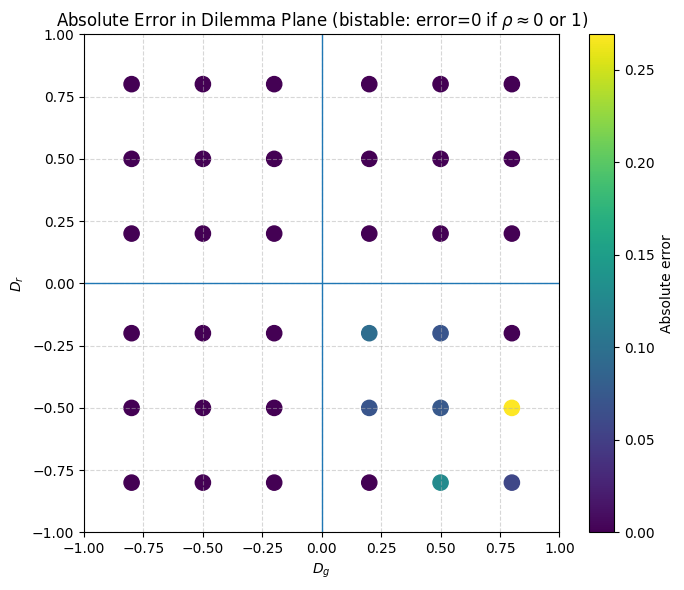

In [243]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import os

agg_path  = "comparison_tables/aggregated.csv"
runs_path = "comparison_tables/runs.csv"

# How close to 0 or 1 counts as "equal"
EPS = 1e-3  # adjust if you want (e.g., 1e-2)

# ---------------------------
# Load
# ---------------------------
if os.path.exists(agg_path):
    df = pd.read_csv(agg_path)
    sim = df["rho_tail_mean_mean"].to_numpy()
elif os.path.exists(runs_path):
    df = pd.read_csv(runs_path)
    sim = df["rho_tail_mean"].to_numpy()
else:
    raise FileNotFoundError("Missing comparison_tables/aggregated.csv and runs.csv")

Dg = df["D_g"].to_numpy()
Dr = df["D_r"].to_numpy()

pred = df.get("rho_pred_graph", pd.Series(np.nan, index=df.index)).to_numpy()
pred_type = df.get("pred_type", pd.Series("", index=df.index)).astype(str).to_numpy()

# ---------------------------
# Compute abs_error
# ---------------------------
abs_error = np.full(len(df), np.nan, dtype=float)

# 1) Unique prediction -> standard abs error
mask_unique = np.isfinite(pred)
abs_error[mask_unique] = np.abs(sim[mask_unique] - pred[mask_unique])

# 2) Bistable: set error=0 if sim is (approximately) 0 or 1
mask_bistable = (pred_type == "bistable") | ((~np.isfinite(pred)) & (pred_type == "bistable"))
mask_sim_at_0_or_1 = (sim <= EPS) | (sim >= 1.0 - EPS)
abs_error[mask_bistable & mask_sim_at_0_or_1] = 0.0

# If you ALSO want a non-NaN error when sim is interior in bistable region,
# uncomment this (distance to nearest stable boundary):
# abs_error[mask_bistable & ~mask_sim_at_0_or_1] = np.minimum(sim[mask_bistable & ~mask_sim_at_0_or_1],
#                                                             1.0 - sim[mask_bistable & ~mask_sim_at_0_or_1])

df["abs_error_custom"] = abs_error

# ---------------------------
# Plot in dilemma plane
# ---------------------------
mask_plot = np.isfinite(df["abs_error_custom"]) & np.isfinite(Dg) & np.isfinite(Dr)

plt.figure(figsize=(7, 6))
sc = plt.scatter(Dg[mask_plot], Dr[mask_plot], c=abs_error[mask_plot], s=120)

plt.axhline(0, lw=1)
plt.axvline(0, lw=1)
plt.xlim(-1, 1)
plt.ylim(-1, 1)
plt.xlabel(r"$D_g$")
plt.ylabel(r"$D_r$")
plt.title(r"Absolute Error in Dilemma Plane (bistable: error=0 if $\rho\approx 0$ or $1$)")

cbar = plt.colorbar(sc)
cbar.set_label(r"Absolute error")

plt.grid(True, linestyle="--", alpha=0.5)
plt.tight_layout()
plt.show()

## Comparison Simulation with RE on graphs with 3x3 subplots

In [211]:
import os
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.ticker import MaxNLocator

# Assumes you already have:
# - cfg
# - safe_tag(x)
# - self_tag()
# - omega_tag_from_value(omega)
# - results_path_for(D_g, D_r, rho0, omega, run=0)

# =========================================================
# 1) Game classification
# =========================================================
def game_class(D_g, D_r):
    if D_g > 0 and D_r > 0:
        return "PD"
    if D_g > 0 and D_r < 0:
        return "SD"
    if D_g < 0 and D_r > 0:
        return "SH"
    if D_g < 0 and D_r < 0:
        return "HG"
    return "axis"


# =========================================================
# 2) Replicator-on-graphs prediction
# =========================================================
def degree_from_cfg():
    if str(cfg.neighborhood) == "4":
        return 4
    if str(cfg.neighborhood) == "8":
        return 8
    raise ValueError("cfg.neighborhood must be '4' or '8'")

def rho_star_graph(D_g, D_r, k):
    denom = D_r - D_g
    if abs(denom) < 1e-12:
        return None
    return (D_r + (D_r + D_g)/(k - 2)) / denom

def L_rho(D_g, D_r, k, rho):
    return rho * (D_r - D_g) - D_r - (D_r + D_g)/(k - 2)

def stable_equilibria_graph(D_g, D_r, k):
    """
    Returns a list of stable equilibria predicted by the replicator equation on graphs.
    Possible outputs:
      [0.0]
      [1.0]
      [rho_star]
      [0.0, 1.0]   (bistable case)
      []
    """
    stables = []

    rho0_stable = (L_rho(D_g, D_r, k, 0.0) < 0.0)
    rho1_stable = (L_rho(D_g, D_r, k, 1.0) > 0.0)

    if rho0_stable:
        stables.append(0.0)
    if rho1_stable:
        stables.append(1.0)

    rstar = rho_star_graph(D_g, D_r, k)
    interior_present = (rstar is not None) and (0.0 < rstar < 1.0)
    interior_stable = (D_r - D_g) < 0.0

    if interior_present and interior_stable:
        stables = [float(rstar)]

    return stables


# =========================================================
# 3) Tail-window statistics
# =========================================================
def tail_stats(rho, frac=0.10):
    n = len(rho)
    if n == 0:
        return np.nan, np.nan, 0
    w = max(1, int(np.floor(frac * n)))
    tail = rho[-w:]
    mean = float(np.mean(tail))
    std = float(np.std(tail, ddof=1)) if w > 1 else 0.0
    return mean, std, w


# =========================================================
# 4) Main plotting function
# =========================================================
def plot_9_games_with_tail_and_theory(
    game_pairs,
    rho0,
    omega,
    run=0,
    out_dir="thesis_figures_tail_theory",
    fmt=("pdf", "png"),
    tail_frac=0.10,
    show_missing=False,
):
    """
    Creates 4 figures (PD, SD, SH, HG), each as a 3x3 grid.
    In each subplot:
      - rho(t) curve for the chosen rho0
      - solid horizontal line: mean over last 10%
      - dashed horizontal lines: mean +/- std over last 10%
      - horizontal line(s): stable equilibrium(a) from replicator equation on graphs
    """

    omtag = omega_tag_from_value(omega)
    save_dir = os.path.join(out_dir, omtag, self_tag())
    os.makedirs(save_dir, exist_ok=True)

    k = degree_from_cfg()

    by_class = {"PD": [], "SD": [], "SH": [], "HG": [], "axis": []}
    for (D_g, D_r) in game_pairs:
        by_class[game_class(D_g, D_r)].append((D_g, D_r))

    for cls in ["PD", "SD", "SH", "HG"]:
        pairs = by_class[cls]
        if len(pairs) == 0:
            continue

        pairs = sorted(pairs, key=lambda x: (x[1], x[0]))

        nrows, ncols = 3, 3
        fig = plt.figure(figsize=(12.0, 9.8))
        gs = fig.add_gridspec(nrows, ncols)

        fig.suptitle(
            fr"{cls} region ($\omega={omega}$, $\rho_0={rho0}$, {self_tag().replace('_',' ')})",
            fontsize=16,
            y=0.98
        )

        axes = [fig.add_subplot(gs[r, c]) for r in range(nrows) for c in range(ncols)]

        for ax, (D_g, D_r) in zip(axes, pairs):
            path = results_path_for(D_g, D_r, rho0, omega, run=run)

            if not os.path.exists(path):
                if show_missing:
                    ax.text(0.5, 0.5, "Missing", ha="center", va="center", fontsize=11)
                ax.set_axis_off()
                continue

            z = np.load(path, allow_pickle=True)
            if "rho_series" in z.files:
                rho = z["rho_series"].astype(float)
            elif "rho" in z.files:
                rho = z["rho"].astype(float)
            else:
                if show_missing:
                    ax.text(0.5, 0.5, "No rho key", ha="center", va="center", fontsize=11)
                ax.set_axis_off()
                continue

            if len(rho) == 0:
                ax.set_axis_off()
                continue

            mcs = np.arange(len(rho)) * cfg.record_every

            # --- plot rho(t)
            ax.plot(mcs, rho, lw=1.8, label=r"$\rho(t)$")

            # --- tail stats
            mean_tail, std_tail, w = tail_stats(rho, frac=tail_frac)

            # mean over last 10%
            ax.axhline(mean_tail, lw=2.0, color="C1", label="tail mean")

            # mean +/- std
            ax.axhline(mean_tail + std_tail, lw=1.5, ls="--", color="C1",
                       label=r"tail mean $\pm$ std")
            ax.axhline(mean_tail - std_tail, lw=1.5, ls="--", color="C1")

            # --- theory stable equilibria
            stables = stable_equilibria_graph(D_g, D_r, k)
            for idx, eq in enumerate(stables):
                if idx == 0:
                    ax.axhline(eq, lw=2.0, color="C3", alpha=0.9,
                               label="stable equilibrium (theory)")
                else:
                    ax.axhline(eq, lw=2.0, color="C3", alpha=0.9)

            # styling
            ax.set_title(fr"$D_g={D_g}$, $D_r={D_r}$", fontsize=11)
            ax.set_ylim(0, 1)
            ax.set_xlim(0, mcs[-1])
            ax.grid(True, linestyle="--", alpha=0.35)

            ax.xaxis.set_major_locator(MaxNLocator(4))
            ax.yaxis.set_major_locator(MaxNLocator(4))
            ax.tick_params(axis="x", labelsize=9)
            ax.tick_params(axis="y", labelsize=9)

            # tail stats annotation
            ax.text(
                0.02, 0.90,
                fr"$\bar{{\rho}}={mean_tail:.3f}$" + "\n" + fr"$\sigma={std_tail:.3f}$",
                transform=ax.transAxes, fontsize=9, va="top",
                bbox=dict(boxstyle="round,pad=0.2", facecolor="white", alpha=0.7, edgecolor="none")
            )

        for ax in axes[len(pairs):]:
            ax.set_axis_off()

        # Outer labels only
        for r in range(nrows):
            for c in range(ncols):
                ax = axes[r * ncols + c]
                if not ax.has_data():
                    continue

                if r == nrows - 1:
                    ax.set_xlabel("MCS", fontsize=11)
                else:
                    ax.set_xlabel("")

                if c == 0:
                    ax.set_ylabel(r"$\rho$", fontsize=11)
                else:
                    ax.set_ylabel("")

        # Collect legend entries
        handles, labels = None, None
        for ax in axes:
            if ax.has_data():
                handles, labels = ax.get_legend_handles_labels()
                break

        if handles:
            uniq = {}
            for h, l in zip(handles, labels):
                if l not in uniq:
                    uniq[l] = h

            fig.legend(
                uniq.values(), uniq.keys(),
                loc="upper center",
                bbox_to_anchor=(0.5, 0.94),
                ncol=3,
                fontsize=11,
                frameon=False
            )

        # Extra space for title + legend
        fig.tight_layout(rect=[0, 0, 1, 0.88])

        base = (
            f"{cls}__grid_3x3__rho0_{safe_tag(rho0)}__"
            f"{omtag}__{self_tag()}__run_{run}"
        )

        for ext in fmt:
            out_path = os.path.join(save_dir, f"{base}.{ext}")
            if ext.lower() == "png":
                fig.savefig(out_path, dpi=350, bbox_inches="tight")
            else:
                fig.savefig(out_path, bbox_inches="tight")
            print("Saved:", os.path.abspath(out_path))

        plt.close(fig)

    if len(by_class["axis"]) > 0:
        print("Note: points on axes (Dg==0 or Dr==0) were not plotted:", by_class["axis"])

In [223]:
my_games = [
    (0.2,0.2), (0.2,0.5), (0.2,0.8),
    (0.5,0.2), (0.5,0.5), (0.5,0.8),
    (0.8,0.2), (0.8,0.5), (0.8,0.8),
    (-0.2,0.2), (-0.2,0.5), (-0.2,0.8),
    (-0.5,0.2), (-0.5,0.5), (-0.5,0.8),
    (-0.8,0.2), (-0.8,0.5), (-0.8,0.8),
    (0.2,-0.2), (0.2,-0.5), (0.2,-0.8),
    (0.5,-0.2), (0.5,-0.5), (0.5,-0.8),
    (0.8,-0.2), (0.8,-0.5), (0.8,-0.8),
    (-0.8,-0.2), (-0.8,-0.5), (-0.8,-0.8),
    (-0.5,-0.2), (-0.5,-0.5), (-0.5,-0.8),
    (-0.2,-0.2), (-0.2,-0.5), (-0.2,-0.8),
]

plot_9_games_with_tail_and_theory(
    game_pairs=my_games,
    rho0=0.5,
    omega=0.2,
    run=0,
    out_dir="thesis_figures_tail_theory",
    fmt=("pdf", "png"),
    tail_frac=0.10,
    show_missing=True
)

Saved: c:\Users\HP\OneDrive\Python\master_thesis\evolutionary_PD_on_a_square_lattice\thesis_figures_tail_theory\omega_0p2\self_off\PD__grid_3x3__rho0_0p5__omega_0p2__self_off__run_0.pdf
Saved: c:\Users\HP\OneDrive\Python\master_thesis\evolutionary_PD_on_a_square_lattice\thesis_figures_tail_theory\omega_0p2\self_off\PD__grid_3x3__rho0_0p5__omega_0p2__self_off__run_0.png
Saved: c:\Users\HP\OneDrive\Python\master_thesis\evolutionary_PD_on_a_square_lattice\thesis_figures_tail_theory\omega_0p2\self_off\SD__grid_3x3__rho0_0p5__omega_0p2__self_off__run_0.pdf
Saved: c:\Users\HP\OneDrive\Python\master_thesis\evolutionary_PD_on_a_square_lattice\thesis_figures_tail_theory\omega_0p2\self_off\SD__grid_3x3__rho0_0p5__omega_0p2__self_off__run_0.png
Saved: c:\Users\HP\OneDrive\Python\master_thesis\evolutionary_PD_on_a_square_lattice\thesis_figures_tail_theory\omega_0p2\self_off\SH__grid_3x3__rho0_0p5__omega_0p2__self_off__run_0.pdf
Saved: c:\Users\HP\OneDrive\Python\master_thesis\evolutionary_PD_on_a_